In [47]:
import numpy as np
from matplotlib import pyplot as plt

Task 1. Simulate a path of the Wiener process. Number of end-points of the grid including $T$ is $N=100$, length of the interval $[0, T]$ in time units is 1, time increment is $\Delta = T/N$. Plot the path.

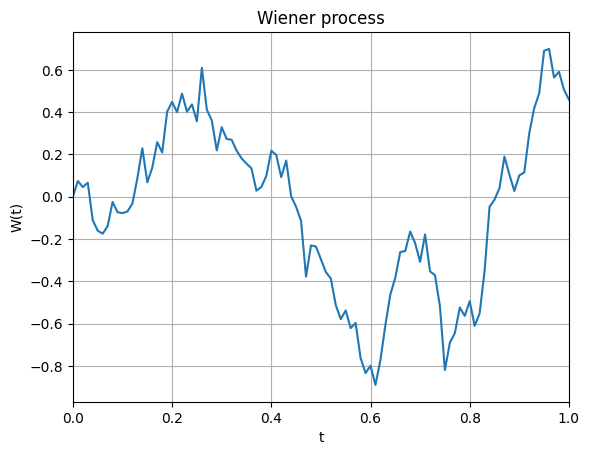

In [48]:
def WienerRandomValue(t):
    return np.sqrt(t) * np.random.normal(0, 1) #генерирует норм сл величину


def WienerProcess(N, T):
    t_data = np.linspace(0, T, N + 1) #массив с равномерно распределёнными значениями в заданном интервале
    w_data = np.zeros(N + 1) #массив значений процесса
    dt = T/N
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] + WienerRandomValue(dt)
    return t_data, w_data

N = 100
T = 1
t_data, w_data = WienerProcess(N, T)

plt.plot(t_data, w_data)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.xlim(0.0, T)
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 2. Using the random walk algorithm simulate three paths of the Wiener process as the limit of a random walk for different $n=10, 100, 1000$. Plot the paths in one figure, add the legend.

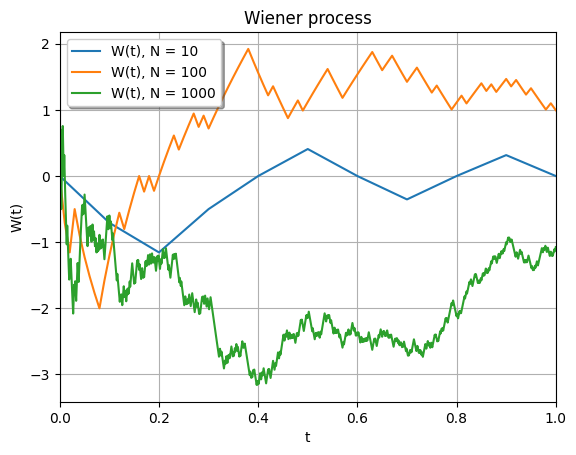

In [49]:
def RandomValueP(p):
    assert p > 0.0 and p < 1.0, '0 < p < 1'

    rand = np.random.uniform(0, 1)
    if rand <= p:
        return 1
    else:
        return -1

def RandomWalk(p, N):
    t_data = np.linspace(0, 1, N + 1)
    w_data = np.zeros(N + 1)
    for i in range(1, N + 1):
        w_data[i] = w_data[i - 1] * np.sqrt(i / (i + 1)) + RandomValueP(p) / np.sqrt(i + 1)
    return t_data, w_data

p = 0.5
N = [10, 100, 1000]
for k in N:
    t_data, w_data = RandomWalk(p, k)
    plt.plot(t_data, w_data, label = f"W(t), N = {k}")

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Wiener process")
plt.grid(True)
plt.show()

Task 3. Using the the Karhunen-Loeve expansion simulate three paths of the Wiener process with
$n = 10, 50, 100$ terms. Plot the paths in one figure, add legends.

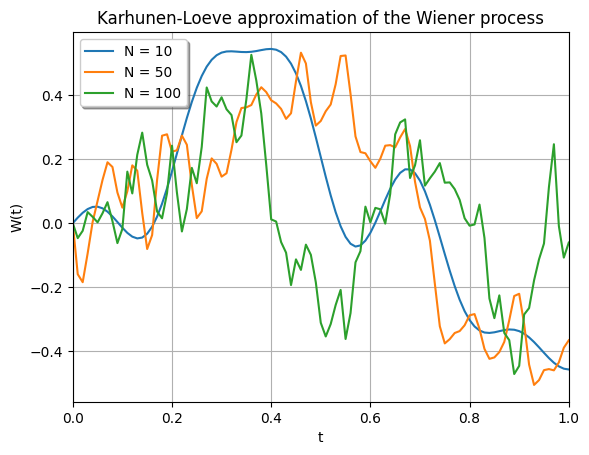

In [50]:
def phi(k, t, T):
    return 2 * np.sqrt(2 * T) / np.pi / (2 * k + 1) * np.sin((2 * k + 1) * np.pi * t / (2 * T))

def KarhunenLoeveApprox(T, Nt, Nz):
    z_data = np.random.normal(0, 1, size = Nz) #генерация независимых коэффициентов
    t_data = np.linspace(0, T, Nt + 1)
    k = np.arange(0, len(z_data)) + 1
    w_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        phi_data = phi(k, t_data[i], T)
        w_data[i] = np.dot(z_data, phi_data)
    return t_data, w_data

T = 1
Nt = 100
Nz = [10, 50, 100]

for k in Nz:
    t_data, w_data = KarhunenLoeveApprox(T, Nt, k)
    plt.plot(t_data, w_data, label = f'N = {k}')

plt.legend(loc = 'upper left', fancybox = True, shadow = True)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("W(t)")
plt.title("Karhunen-Loeve approximation of the Wiener process")
plt.grid(True)
plt.show()

Task 4. Plot a trajectory of the geometric Brownian motion obtained from the simulation of the path of the Wiener process, $r=1$ (interest rate) and $\sigma = 0.5$ (volatility).

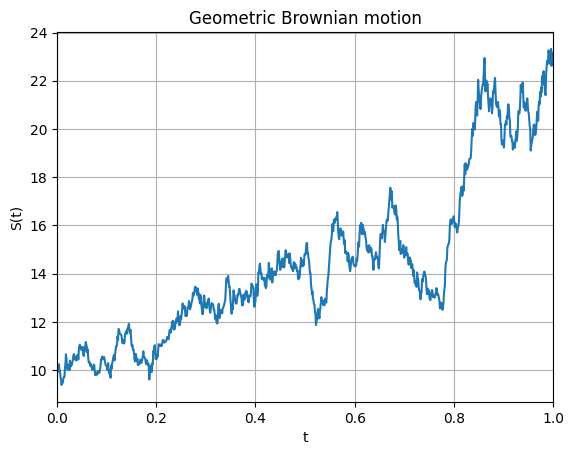

In [51]:
def GeometricBrownianMotion(S0, r, sigma, T):
    Nt = 1000
    t_data = np.linspace(0, T, Nt + 1)
    s_data = np.zeros(Nt + 1)
    s_data[0] = S0
    dt = T / Nt
    for i in range(1, Nt + 1):
        s_data[i] = s_data[i-1] * np.exp((r - sigma**2 / 2)* dt + sigma * WienerRandomValue(dt))
    return t_data, s_data

S0 = 10
r = 1
sigma = 0.5
T = 1

t_data, s_data = GeometricBrownianMotion(S0, r, sigma, T)
plt.plot(t_data, s_data)
plt.xlim(0.0, 1.0)
plt.xlabel("t")
plt.ylabel("S(t)")
plt.title("Geometric Brownian motion")
plt.grid(True)
plt.show()

Task 5. Plot a trajectory of the the Brownian bridge starting at $x$ at time $0$ and terminating its run at $y =-1$ at time $T$ obtained from the simulation of the path of the Wiener process. Add markers for start and end points.

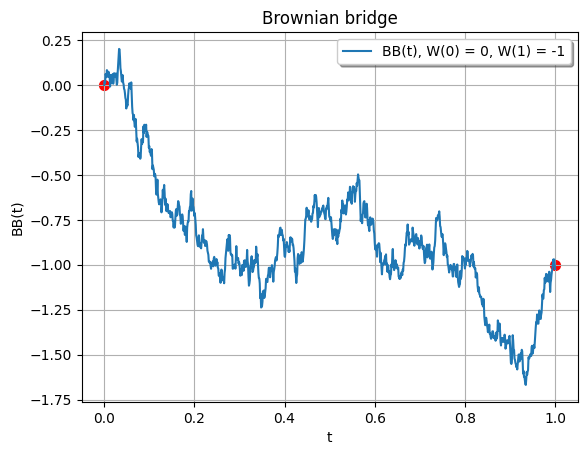

In [52]:
def BrownianBridge(x, y, t0, T):
    Nt = 1000
    t_data, w_data = WienerProcess(Nt, T)
    dt = T/Nt
    bb_data = np.zeros(Nt + 1)
    for i in range(0, Nt + 1):
        bb_data[i] = x + w_data[i] - (t_data[i] - t0) / (T - t0) * (w_data[Nt - 1] - y + x)
    return t_data, bb_data

x = 0
y = -1
t0 = 0
T = 1
t_data, bb_data = BrownianBridge(x, y, t0, T)

plt.plot(t_data, bb_data, label = f"BB(t), W({t0}) = {x}, W({T}) = {y}")
plt.scatter ( t0, x, color = "red", s = 50)
plt.scatter ( T, y, color = "red", s = 50)
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("BB(t)")
plt.title("Brownian bridge")
plt.grid(True)
plt.show()

# Exercises

Exercise 1. Let us consider a random walk $X = (X_n)_{n \geq 0}$:
$$
X_n = \sum_{k=1}^n \xi_k, \quad \xi_k =
\begin{cases}
1, &\text{with probability $\frac12$}; \\
-1, &\text{with probability $\frac12$}.
\end{cases}
$$
$$
\mathbb{E}\xi_k = 0, \quad \mathrm{Var}\, \xi_k = 1.
$$

Plot $(X_{t_i})_{t_i = \frac{i}{n}}$ so that $t_i$ takes values in $[0,\, 1]$.

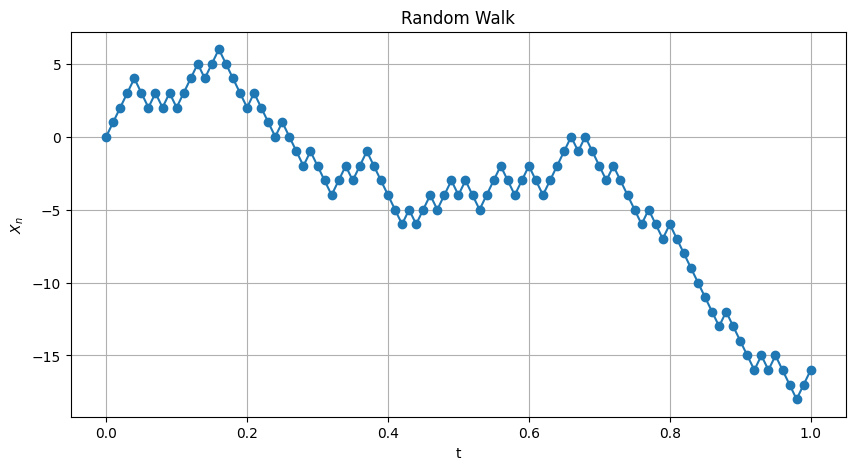

In [53]:
def RandomWalk(N, p=[0.5, 0.5]):
    # Генерируем случайные шаги
    xi = np.random.choice([-1, 1], size=N, p=p)

    # Вычисляем случайное блуждание
    X = np.cumsum(xi)  # Кумулятивная сумма шагов

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)  # Добавляем X_0 = 0 в начало

    # Создаем массив t
    t = np.linspace(0, 1, N + 1)  # n + 1 точек для t_i
    return t, X
    # Строим график
N = 100
t, X = RandomWalk(N)

plt.figure(figsize=(10,5))
plt.plot(t, X, marker='o')
plt.title('Random Walk')
plt.xlabel('t')
plt.ylabel('$X_n$')
plt.grid()
plt.show()

Exercise 2. Let $H = (H_n)_{n \geq 1}$ be the player's bet at the $n$-th step, i.e. his winnings at this step are equal to $H_n (X_n - X_{n-1}) = H_n \Delta X_n$.

Plot an accumulated winnings of player $Y_n$ at step $n \geq 1$.


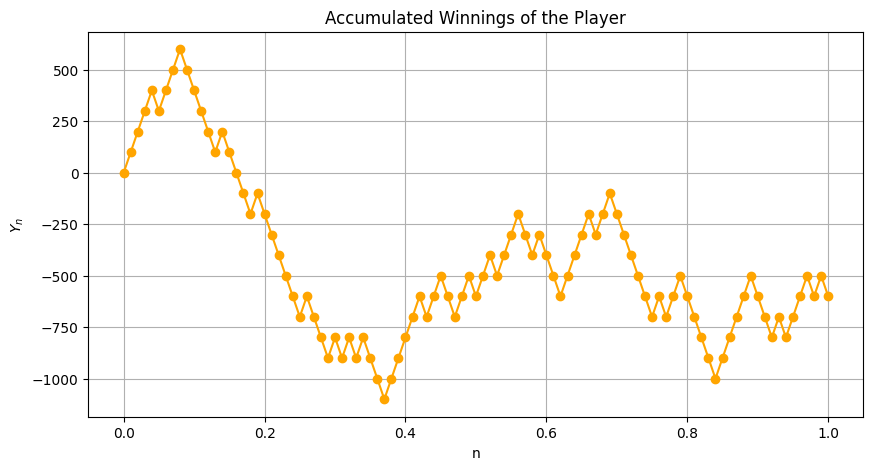

In [54]:
def random_walk_with_bets(n, H):
    # Генерируем случайные шаги
    xi = np.random.choice([-1, 1], size=n, p=[0.5, 0.5])

    # Вычисляем случайное блуждание
    X = np.cumsum(xi)

    # Добавляем начальную позицию (0)
    X = np.insert(X, 0, 0)  # Добавляем X_0 = 0 в начало

    # Вычисляем накопленные выигрыши
    Y = np.zeros(n + 1)  # Начинаем с 0
    for i in range(1, n + 1):
        Y[i] = Y[i - 1] + H * (X[i] - X[i - 1])  # Y_n = Y_{n-1} + H * ΔX_n

    # Создаем массив t
    t = np.linspace(0, 1, n + 1)  # n + 1 точек для t_i

    # Строим график накопленных выигрышей
    plt.figure(figsize=(10, 5))
    plt.plot(t, Y, marker='o', linestyle='-', color='orange')
    plt.title('Accumulated Winnings of the Player')
    plt.xlabel('n')
    plt.ylabel('$Y_n$')
    plt.grid()
    plt.show()

# Пример вызова функции с n = 100 и H = 1
random_walk_with_bets(100, H=100)

# Задачи

Задача 1. Квадратичная вариация (Раздел 1.1.2)

Для траектории винеровского процесса при $T=1$ и разного числа интервалов разбиения $\{10,100,1000,10000\}$:

1. Вычислите сумму квадратов приращений $$ S_n= ∑_{k=0}^{n−1}​ ∣W(t_{k+1} )−W(t_k​ )∣^2.$$

2. Постройте график зависимости суммы $S_n$ от числа интервалов разбиения (столбчатую диаграмму).

3. Сделайте выводы.

N = 10, S_n = 0.9432512272331759
N = 100, S_n = 0.7699220898138356
N = 500, S_n = 0.9292691092896858
N = 1000, S_n = 0.9834817087273184


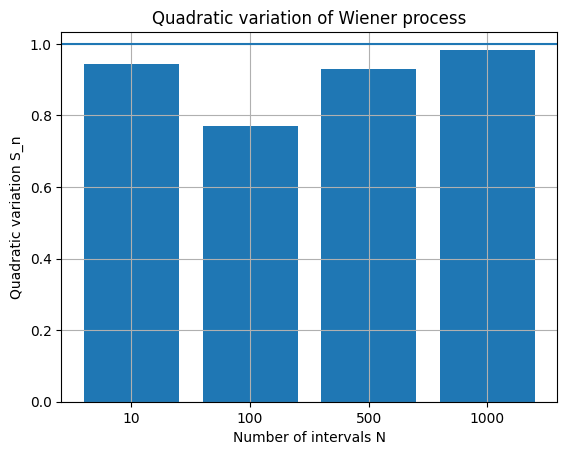

In [61]:
def QuadraticVariation(w_data): #вычисление квадратичной вариации
    increments = np.diff(w_data) #приращения
    return np.sum(increments**2)
T = 1
N_values = [10, 100, 500, 1000]

S_values = []

for N in N_values:
    t_data, w_data = WienerProcess(N, T)
    S_n = QuadraticVariation(w_data)
    S_values.append(S_n)
    print(f"N = {N}, S_n = {S_n}")
plt.figure()
plt.bar([str(N) for N in N_values], S_values)
plt.axhline(y=T)  # теоретическое значение
plt.xlabel("Number of intervals N")
plt.ylabel("Quadratic variation S_n")
plt.title("Quadratic variation of Wiener process")
plt.grid(True)
plt.show()



Чем выше N (число разбиений) тем ближе к 1 сумма квадратов приращений

Задача 2. Эмпирическая ковариационная функция (Раздел 1.1.3)

Для винеровского процесса теоретическая ковариация между состояниями в моменты времени $s$ и $t$ равна $\min(s,t)$.

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Вычислите выборочную ковариацию между точками $t=0.5$ и $t=T$ и сравните полученное число с теоретическим значением $0.5$.

3. Сделайте выводы.

In [71]:
T = 1
N = 1000 #число шагов
M = 500   # количество траекторий

W_half = []
W_T = []

for _ in range(M):
    t_data, w_data = WienerProcess(N, T)#генерация независимых траекторий

    index_half = int(0.5 * N)   # индекс времени для t=0.5
    index_T = N                 # индекс для t=1

    W_half.append(w_data[index_half]) #сохранение значений процесса
    W_T.append(w_data[index_T])

W_half = np.array(W_half)
W_T = np.array(W_T)
empirical_cov = np.cov(W_half, W_T, ddof=1)[0,1] #вычисление ковариации

print("Empirical covariance:", empirical_cov)
print("Theoretical covariance:", 0.5)


Empirical covariance: 0.5119289789716934
Theoretical covariance: 0.5


Выборочная ковариация близка к теоретическому значению, подтверждаеся, что ковариационная функция винеровского процесса равна $\min(s,t)$

Задача 3. Тестирование мартингального свойства (Раздел 1.1.5)

1. Сгенерируйте ансамбль из 500 траекторий винеровского процесса.

2. Выберите фиксированный момент времени $s=0.4$.

3. Для всех сгенерированных траекторий, проходящих через определенный узкий диапазон значений в момент $s$, вычислите среднее арифметическое их значений в финальный момент $T$.

4. Сравните полученное среднее арифметическое со значением процесса в момент $s$.

5. Сделайте выводы. Проанализовать как диапозон влияет на результат.

In [75]:
T = 1
N = 1000 #число шагов
M = 500   # количество траекторий
s=0.4

index_s = int(s * N)

trajectories = []
#генерируется 500 независимых траекторий
for _ in range(M):
    _, w_data = WienerProcess(N, T)
    trajectories.append(w_data)

trajectories = np.array(trajectories)

target_value = 0.5
epsilon = 0.05   # ширина диапазона
W_s = trajectories[:, index_s] #значения в момент времени s
W_T = trajectories[:, -1] #значения в момент времени T

mask = np.abs(W_s - target_value) < epsilon #логический массив для отбора попавших траекторий в диапазон

selected_W_T = W_T[mask]
selected_W_s = W_s[mask]

#вычисление среднего
mean_W_T = np.mean(selected_W_T)
mean_W_s = np.mean(selected_W_s)

print("Average W(s):", mean_W_s)
print("Average W(T):", mean_W_T)
print("Number of selected trajectories:", len(selected_W_T))

Average W(s): 0.4993779128094783
Average W(T): 0.4950981338945923
Number of selected trajectories: 22


Подтверждается, что условное математическое ожидание будущего значения процесса при фиксированном текущем значении равно этому текущему значению.

Задача 4. Анализ независимости приращений (Раздел 1.2)

1. Выберите два непересекающихся интервала $[t_1, t_2​]$ и $[t_3, t_4​]$.
2. Сгенерируйте $M$ траекторий и вычислите приращения
$ΔW_1 =W(t_2)−W(t_1)$ и $ΔW_2 =W(t_4)−W(t_3)$.

3. Постройте диаграмму рассеяния (scatter plot) для $(ΔW_1, ΔW_2)$ и вычислите коэффициент корреляции.

4. Сравните полученное значение с нулем и сделайте выводы.

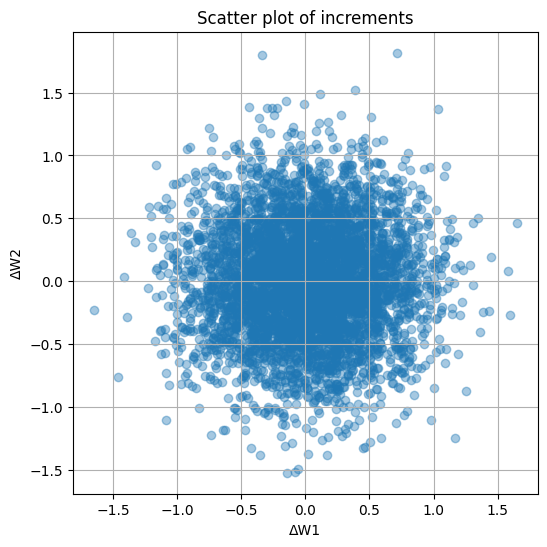

Empirical correlation: 0.0005953409303457163


In [58]:
T = 1
N = 1000 #число шагов
M = 5000 #число траекторий

# интервалы
t1, t2 = 0.2, 0.4
t3, t4 = 0.6, 0.8

index_t1 = int(t1 * N)
index_t2 = int(t2 * N)
index_t3 = int(t3 * N)
index_t4 = int(t4 * N)

delta_W1 = []
delta_W2 = []

for _ in range(M):
    _, w_data = WienerProcess(N, T) #генерация независимых траекторий
    #вычисление приращений
    d1 = w_data[index_t2] - w_data[index_t1]
    d2 = w_data[index_t4] - w_data[index_t3]

    delta_W1.append(d1)
    delta_W2.append(d2)

delta_W1 = np.array(delta_W1)
delta_W2 = np.array(delta_W2)
plt.figure(figsize=(6,6))
plt.scatter(delta_W1, delta_W2, alpha=0.4)
plt.xlabel("ΔW1")
plt.ylabel("ΔW2")
plt.title("Scatter plot of increments")
plt.grid(True)
plt.show()
correlation = np.corrcoef(delta_W1, delta_W2)[0,1]

print("Empirical correlation:", correlation)

Корреляция между приращениями на непересекающихся интервалах близка к 0. На диаграмме рассеяния нет линейной зависимости.
Подтверждается свойство винеровского процесса о независимости приращений


Задача 5. Точность разложения Карунена-Лоэва (Раздел 1.2.3)

1. Реализуйте аппроксимацию винеровской траектории, используя $n=10, 100, 1000$ слагаемых.
2. Рассчитайте среднеквадратичную ошибку между прямой симуляцией и аппроксимацией Карунена-Лоэва.

3. Постройте график зависимости ошибки при увеличении числа членов ряда $n$.
4. Сделайте выводы.


Результаты:
n=  10, MSE=0.011643
n= 100, MSE=0.000808
n=1000, MSE=0.000000


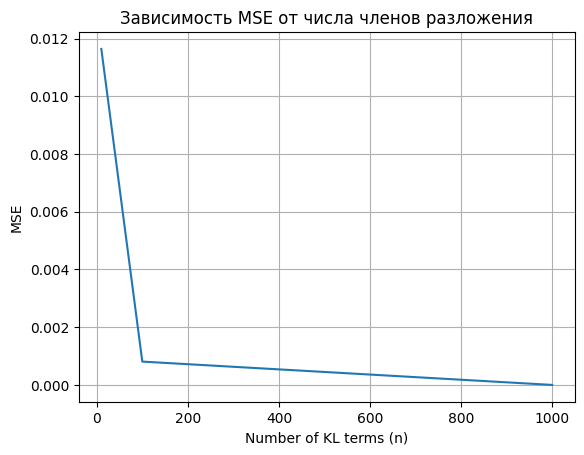

In [151]:

def KL_Wiener(t, n_terms, xi):
    W_approx = np.zeros_like(t)
    T = 1
    for k in range(n_terms):
        coefficient = 2*np.sqrt(2*T) / ((2*k + 1) * np.pi) #разложение
        W_approx += (
            xi[k] *
            coefficient *
            np.sin(((2*k +1) * np.pi * t)/(2*T))
        )
    return W_approx

N= 1000
T = 1.0
t_kl = np.linspace(0, T, N + 1)
xi = np.random.normal(0, 1, 1000)
w_ref = KL_Wiener(t_kl, 1000, xi)

n_list = [10, 100, 1000]
mse_list = []
print("Результаты:")
for n in n_list:
    w_kl = KL_Wiener(t_kl, n, xi[:n])
    mse = np.mean((w_ref - w_kl)**2)
    mse_list.append(mse)
    print(f"n={n:4d}, MSE={mse:.6f}")

plt.plot(n_list, mse_list)
plt.xlabel('Number of KL terms (n)')
plt.ylabel('MSE')
plt.title('Зависимость MSE от числа членов разложения')
plt.grid(True)
plt.show()



Среднеквадратичная ошибка уменьшается при росте
n (количества слагаемых), что показывает сходимость аппроксимации